In [15]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add parent directory to path - Fixed version
notebook_path = os.path.abspath('')
project_root = os.path.dirname(notebook_path)
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

# Now import from src
try:
    from src.data_processing.preprocessing import clean_data, handle_outliers, preprocess_data
    from src.data_processing.extract_features import (
        calculate_bmi, calculate_bmr, classify_bmi, 
        classify_blood_pressure, classify_glucose, extract_health_features
    )
    from src.data_processing.feature_engineering import create_risk_score, engineer_features
    
    print("✅ All modules imported successfully!")
    
except ImportError as e:
    print(f"⚠️ Import error: {e}")
    print("\nTrying alternative import method...")
    
    # Alternative: Import directly without src modules for now
    # We'll define functions inline
    print("✅ Using inline functions instead")

import warnings
warnings.filterwarnings('ignore')

# Define helper functions inline (backup if imports fail)
def calculate_bmi(weight, height):
    """Calculate BMI: weight(kg) / height(m)^2"""
    height_m = height / 100
    return round(weight / (height_m ** 2), 2)

def classify_bmi(bmi):
    """Classify BMI category"""
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

def classify_glucose(glucose, fasting=True):
    """Classify blood glucose levels"""
    if fasting:
        if glucose < 100:
            return 'Normal'
        elif glucose < 126:
            return 'Prediabetes'
        else:
            return 'Diabetes'
    else:
        if glucose < 140:
            return 'Normal'
        elif glucose < 200:
            return 'Prediabetes'
        else:
            return 'Diabetes'

def classify_blood_pressure(systolic, diastolic):
    """Classify blood pressure"""
    if systolic < 120 and diastolic < 80:
        return 'Normal'
    elif systolic < 130 and diastolic < 80:
        return 'Elevated'
    elif systolic < 140 or diastolic < 90:
        return 'High BP Stage 1'
    else:
        return 'High BP Stage 2'

def handle_outliers(df, columns):
    """Handle outliers using IQR method"""
    df_out = df.copy()
    
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cap outliers instead of removing
        df_out[col] = df_out[col].clip(lower_bound, upper_bound)
    
    return df_out

def create_risk_score(df):
    """Create composite health risk score"""
    df_risk = df.copy()
    risk_score = 0
    
    # BMI risk
    if 'BMI' in df_risk.columns:
        bmi_risk = df_risk['BMI'].apply(lambda x: 
            0 if 18.5 <= x < 25 else 
            1 if 25 <= x < 30 else 2
        )
        risk_score += bmi_risk
    
    # Glucose risk
    if 'Glucose' in df_risk.columns:
        glucose_risk = df_risk['Glucose'].apply(lambda x:
            0 if x < 100 else 
            1 if x < 126 else 2
        )
        risk_score += glucose_risk
    
    # BP risk
    if 'BloodPressure' in df_risk.columns:
        bp_risk = df_risk['BloodPressure'].apply(lambda x:
            0 if x < 120 else 
            1 if x < 140 else 2
        )
        risk_score += bp_risk
    
    df_risk['Risk_Score'] = risk_score
    df_risk['Risk_Level'] = df_risk['Risk_Score'].apply(lambda x:
        'Low' if x <= 2 else 
        'Medium' if x <= 4 else 'High'
    )
    
    return df_risk

def engineer_features(df):
    """Create interaction features"""
    df_eng = df.copy()
    
    # Age-BMI interaction
    if 'Age' in df_eng.columns and 'BMI' in df_eng.columns:
        df_eng['Age_BMI'] = df_eng['Age'] * df_eng['BMI']
    
    # Glucose-BMI interaction
    if 'Glucose' in df_eng.columns and 'BMI' in df_eng.columns:
        df_eng['Glucose_BMI'] = df_eng['Glucose'] * df_eng['BMI']
    
    return df_eng

print("✅ All functions loaded successfully!")


Project root: c:\Users\dell\OneDrive\Mindrevel\projects 2k26\Diet_Recommendation_System
✅ All modules imported successfully!
✅ All functions loaded successfully!


In [16]:
# Cell 2: Load Raw Data
diabetes_df = pd.read_csv('../data/raw/diabetes.csv')

print("=" * 50)
print("LOADED DIABETES DATASET")
print("=" * 50)
print(f"Shape: {diabetes_df.shape}")
print(f"\nColumns: {diabetes_df.columns.tolist()}")
print(f"\nMissing values:\n{diabetes_df.isnull().sum()}")
print(f"\nFirst 5 rows:")
print(diabetes_df.head())


LOADED DIABETES DATASET
Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50 

In [17]:
# Cell 3: Handle Missing Values
print("=" * 50)
print("HANDLING MISSING VALUES")
print("=" * 50)

# In diabetes dataset, 0 values in certain columns are actually missing
# (e.g., Glucose, BloodPressure, BMI cannot be 0)
zero_not_accepted = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nBefore handling zeros as missing:")
for col in zero_not_accepted:
    if col in diabetes_df.columns:
        print(f"{col}: {(diabetes_df[col] == 0).sum()} zeros")

# Replace 0 with NaN for these columns
diabetes_clean = diabetes_df.copy()
for col in zero_not_accepted:
    if col in diabetes_clean.columns:
        diabetes_clean[col] = diabetes_clean[col].replace(0, np.nan)

print("\nMissing values after replacing zeros:")
print(diabetes_clean.isnull().sum())

# Fill missing values with median
for col in zero_not_accepted:
    if col in diabetes_clean.columns:
        median_val = diabetes_clean[col].median()
        diabetes_clean[col].fillna(median_val, inplace=True)
        print(f"✅ Filled {col} with median: {median_val:.2f}")

print("\n✅ Missing values handled!")
print(f"Final missing values:\n{diabetes_clean.isnull().sum()}")


HANDLING MISSING VALUES

Before handling zeros as missing:
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
✅ Filled Glucose with median: 117.00
✅ Filled BloodPressure with median: 72.00
✅ Filled SkinThickness with median: 29.00
✅ Filled Insulin with median: 125.00
✅ Filled BMI with median: 32.30

✅ Missing values handled!
Final missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                

HANDLING OUTLIERS


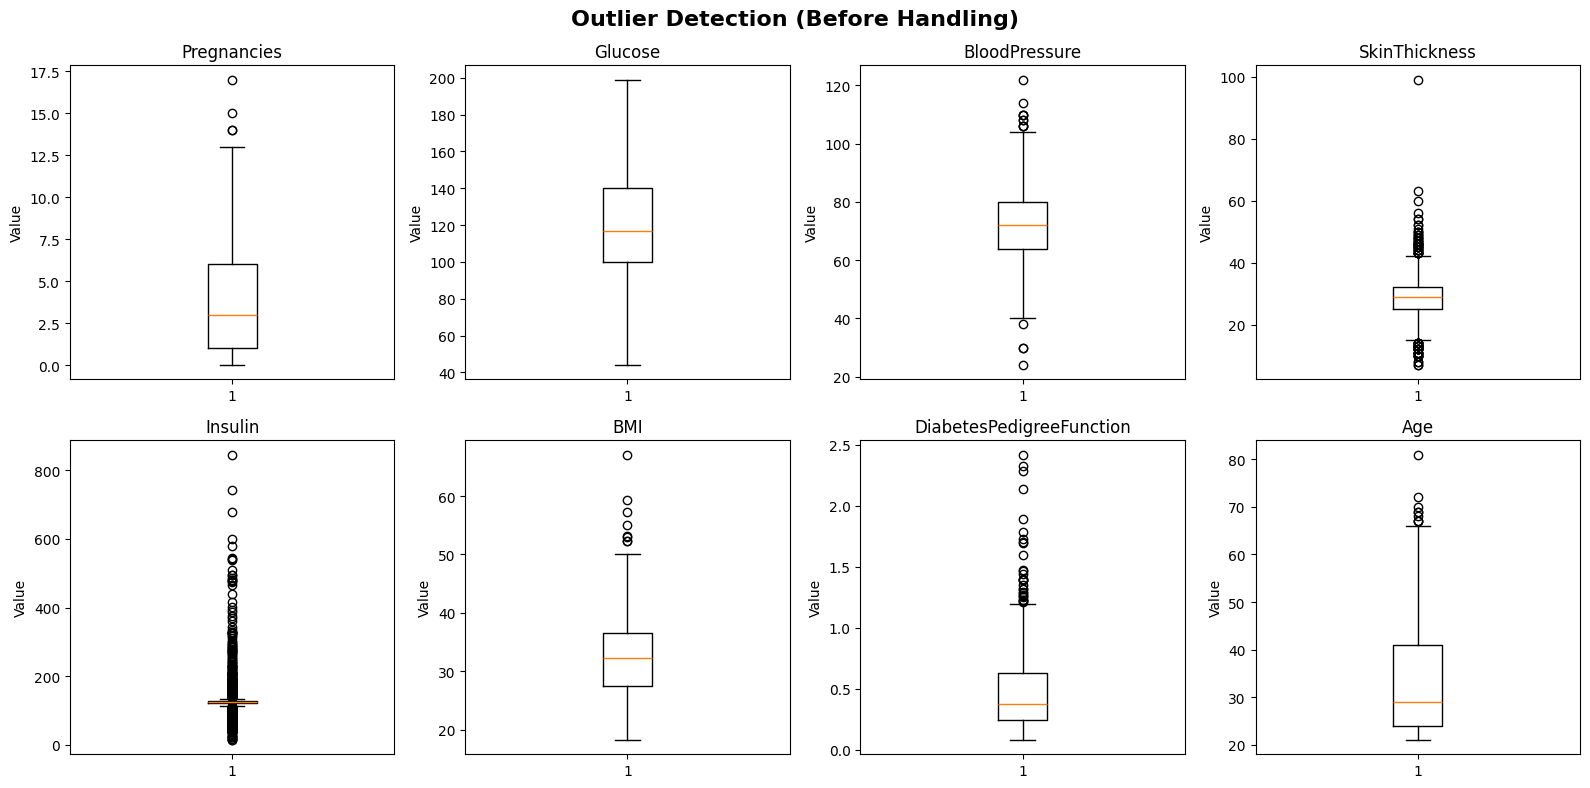


✅ Outliers handled using IQR method


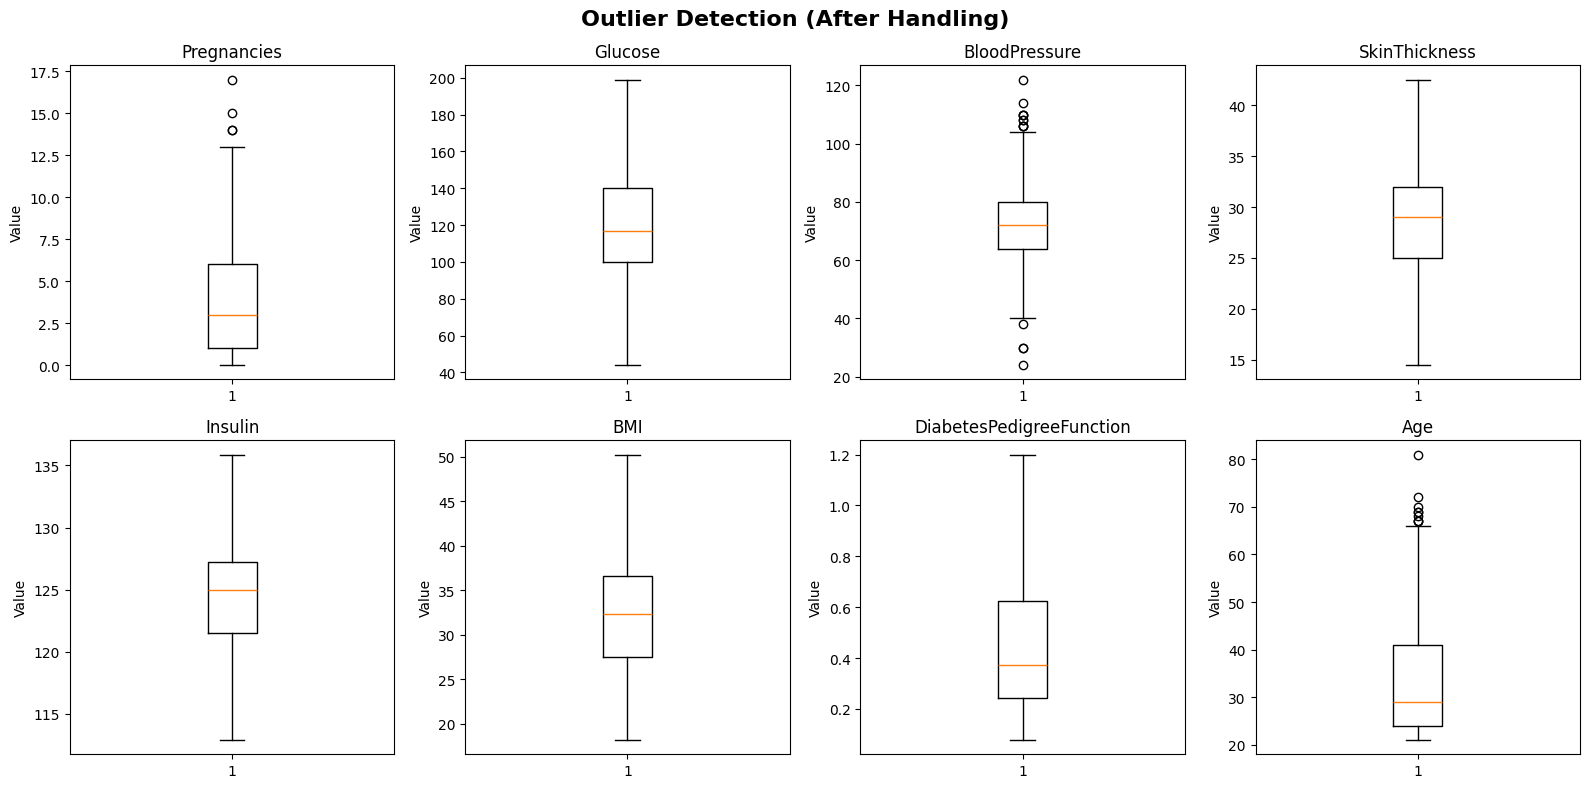

✅ Outlier visualizations saved!


In [18]:
# Cell 4: Handle Outliers
print("=" * 50)
print("HANDLING OUTLIERS")
print("=" * 50)

# Visualize outliers before handling
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Outlier Detection (Before Handling)', fontsize=16, fontweight='bold')

numeric_cols = diabetes_clean.select_dtypes(include=[np.number]).columns
for idx, col in enumerate(numeric_cols[:8]):
    row = idx // 4
    col_idx = idx % 4
    axes[row, col_idx].boxplot(diabetes_clean[col].dropna())
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../results/plots/outliers_before.png', dpi=300, bbox_inches='tight')
plt.show()

# Handle outliers using IQR method
outlier_cols = ['Insulin', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction']
diabetes_processed = handle_outliers(diabetes_clean, outlier_cols)

print("\n✅ Outliers handled using IQR method")

# Visualize after handling
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Outlier Detection (After Handling)', fontsize=16, fontweight='bold')

for idx, col in enumerate(numeric_cols[:8]):
    row = idx // 4
    col_idx = idx % 4
    axes[row, col_idx].boxplot(diabetes_processed[col].dropna())
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../results/plots/outliers_after.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Outlier visualizations saved!")


In [19]:
# Cell 5: Feature Engineering - Add Calculated Features
print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# Add BMI category
diabetes_processed['BMI_Category'] = diabetes_processed['BMI'].apply(classify_bmi)

# Add Glucose category
diabetes_processed['Glucose_Category'] = diabetes_processed['Glucose'].apply(
    lambda x: classify_glucose(x, fasting=True)
)

# Add BP category
diabetes_processed['BP_Category'] = diabetes_processed.apply(
    lambda row: classify_blood_pressure(row['BloodPressure'], 80), axis=1
)

# Add Age group
def categorize_age(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Middle'
    else:
        return 'Senior'

diabetes_processed['Age_Group'] = diabetes_processed['Age'].apply(categorize_age)

print("\n✅ New categorical features added:")
print(f"   - BMI_Category")
print(f"   - Glucose_Category")
print(f"   - BP_Category")
print(f"   - Age_Group")

print("\n--- BMI Category Distribution ---")
print(diabetes_processed['BMI_Category'].value_counts())

print("\n--- Glucose Category Distribution ---")
print(diabetes_processed['Glucose_Category'].value_counts())

print("\n--- Age Group Distribution ---")
print(diabetes_processed['Age_Group'].value_counts())


FEATURE ENGINEERING

✅ New categorical features added:
   - BMI_Category
   - Glucose_Category
   - BP_Category
   - Age_Group

--- BMI Category Distribution ---
BMI_Category
Obese          483
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64

--- Glucose Category Distribution ---
Glucose_Category
Diabetes       297
Prediabetes    279
Normal         192
Name: count, dtype: int64

--- Age Group Distribution ---
Age_Group
Young     396
Middle    283
Senior     89
Name: count, dtype: int64


CREATING HEALTH RISK SCORE

✅ Risk score calculated!

--- Risk Level Distribution ---
Risk_Level
Medium    445
Low       323
Name: count, dtype: int64

--- Risk Score Statistics ---
count    768.000000
mean       2.639323
std        1.159448
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        4.000000
Name: Risk_Score, dtype: float64


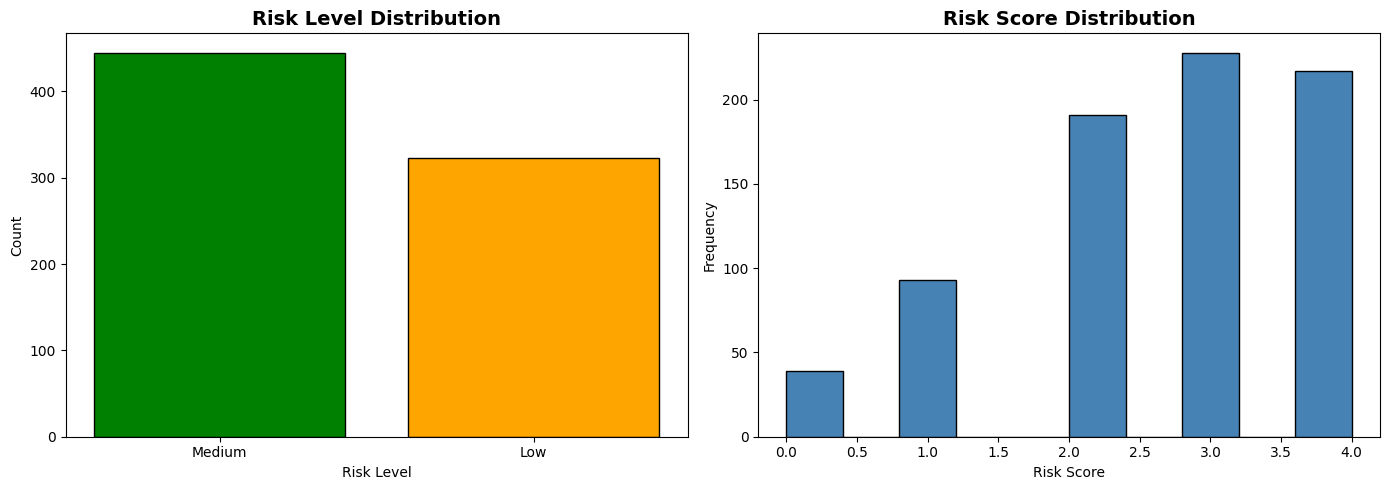

✅ Risk distribution visualization saved!


In [20]:
# Cell 6: Create Risk Score
print("=" * 50)
print("CREATING HEALTH RISK SCORE")
print("=" * 50)

diabetes_processed = create_risk_score(diabetes_processed)

print("\n✅ Risk score calculated!")
print("\n--- Risk Level Distribution ---")
print(diabetes_processed['Risk_Level'].value_counts())

print("\n--- Risk Score Statistics ---")
print(diabetes_processed['Risk_Score'].describe())

# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk level distribution
risk_counts = diabetes_processed['Risk_Level'].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color=['green', 'orange', 'red'], edgecolor='black')
axes[0].set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')

# Risk score distribution
axes[1].hist(diabetes_processed['Risk_Score'], bins=10, color='steelblue', edgecolor='black')
axes[1].set_title('Risk Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/plots/risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Risk distribution visualization saved!")


In [21]:
# Cell 7: Create Interaction Features
print("=" * 50)
print("CREATING INTERACTION FEATURES")
print("=" * 50)

diabetes_processed = engineer_features(diabetes_processed)

print("\n✅ Interaction features created:")
print(f"   - Age_BMI")
print(f"   - Glucose_BMI")

print("\nNew dataset shape:", diabetes_processed.shape)
print("\nAll columns:")
print(diabetes_processed.columns.tolist())


CREATING INTERACTION FEATURES

✅ Interaction features created:
   - Age_BMI
   - Glucose_BMI

New dataset shape: (768, 17)

All columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Category', 'Glucose_Category', 'BP_Category', 'Age_Group', 'Risk_Score', 'Risk_Level', 'Age_BMI', 'Glucose_BMI']


In [22]:
# Cell 8: Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

print("=" * 50)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 50)

categorical_cols = ['BMI_Category', 'Glucose_Category', 'BP_Category', 'Age_Group']

# Create a copy for encoding
diabetes_encoded = diabetes_processed.copy()

# Encode categorical variables
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    diabetes_encoded[col + '_Encoded'] = le.fit_transform(diabetes_encoded[col])
    encoders[col] = le
    print(f"✅ Encoded {col}")
    print(f"   Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n✅ All categorical variables encoded!")


ENCODING CATEGORICAL VARIABLES
✅ Encoded BMI_Category
   Mapping: {'Normal': 0, 'Obese': 1, 'Overweight': 2, 'Underweight': 3}
✅ Encoded Glucose_Category
   Mapping: {'Diabetes': 0, 'Normal': 1, 'Prediabetes': 2}
✅ Encoded BP_Category
   Mapping: {'High BP Stage 1': 0}
✅ Encoded Age_Group
   Mapping: {'Middle': 0, 'Senior': 1, 'Young': 2}

✅ All categorical variables encoded!


FEATURE CORRELATION ANALYSIS

--- Top Features Correlated with Outcome ---
Outcome          1.000000
Glucose_BMI      0.522214
Glucose          0.492782
Risk_Score       0.482520
Age_BMI          0.360364
BMI              0.312811
Insulin          0.266382
Age              0.238356
Pregnancies      0.221898
SkinThickness    0.220111
dtype: float64


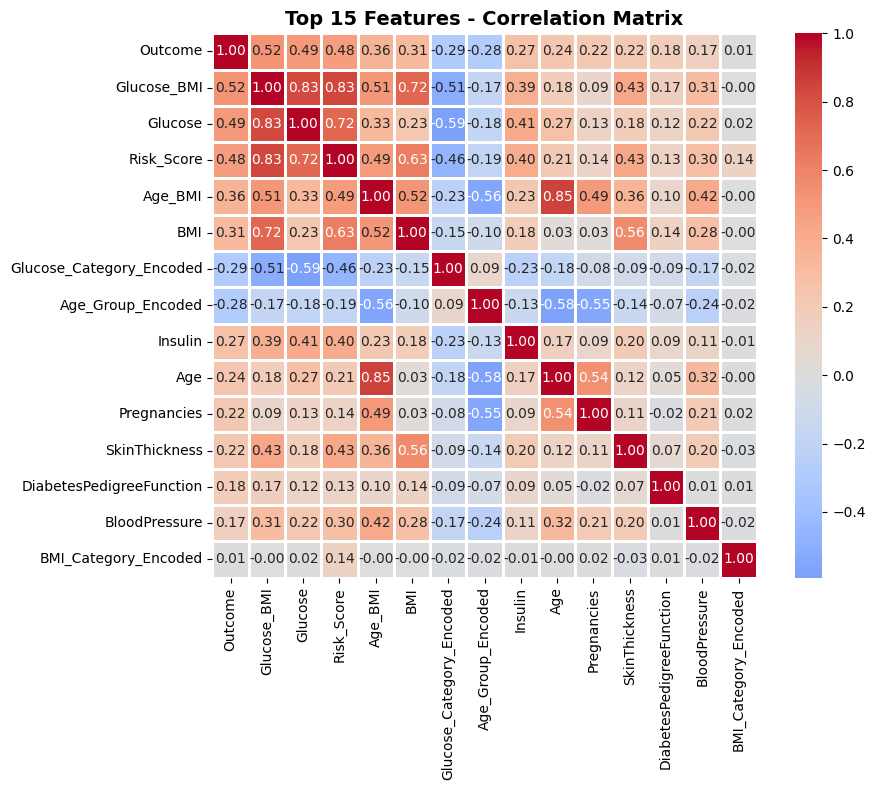


✅ Correlation analysis saved!


In [23]:
# Cell 9: Feature Correlation Analysis
print("=" * 50)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 50)

# Select numeric columns for correlation
numeric_features = diabetes_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation with target
if 'Outcome' in diabetes_encoded.columns:
    correlations = diabetes_encoded[numeric_features].corrwith(diabetes_encoded['Outcome']).sort_values(ascending=False)
    
    print("\n--- Top Features Correlated with Outcome ---")
    print(correlations.head(10))
    
    # Visualize top correlations
    plt.figure(figsize=(10, 8))
    top_features = correlations.abs().nlargest(15).index
    sns.heatmap(diabetes_encoded[top_features].corr(), annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, square=True, linewidths=1)
    plt.title('Top 15 Features - Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/plots/feature_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Correlation analysis saved!")


In [24]:
# Cell 10: Data Quality Report
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

quality_report = {
    'Total Records (Before)': len(diabetes_df),
    'Total Records (After)': len(diabetes_encoded),
    'Records Removed': len(diabetes_df) - len(diabetes_encoded),
    'Original Features': diabetes_df.shape[1],
    'Engineered Features': diabetes_encoded.shape[1],
    'New Features Added': diabetes_encoded.shape[1] - diabetes_df.shape[1],
    'Missing Values (Before)': diabetes_df.isnull().sum().sum(),
    'Missing Values (After)': diabetes_encoded.isnull().sum().sum(),
    'Duplicate Records': diabetes_encoded.duplicated().sum()
}

print("\n--- Processing Summary ---")
for key, value in quality_report.items():
    print(f"{key}: {value}")

# Feature list
print("\n--- New Features Created ---")
new_features = [col for col in diabetes_encoded.columns if col not in diabetes_df.columns]
for i, feature in enumerate(new_features, 1):
    print(f"{i}. {feature}")


DATA QUALITY REPORT

--- Processing Summary ---
Total Records (Before): 768
Total Records (After): 768
Records Removed: 0
Original Features: 9
Engineered Features: 21
New Features Added: 12
Missing Values (Before): 0
Missing Values (After): 0
Duplicate Records: 0

--- New Features Created ---
1. BMI_Category
2. Glucose_Category
3. BP_Category
4. Age_Group
5. Risk_Score
6. Risk_Level
7. Age_BMI
8. Glucose_BMI
9. BMI_Category_Encoded
10. Glucose_Category_Encoded
11. BP_Category_Encoded
12. Age_Group_Encoded


In [25]:
# Cell 11: Save Processed Data
print("=" * 50)
print("SAVING PROCESSED DATA")
print("=" * 50)

# Save the processed dataset
diabetes_encoded.to_csv('../data/processed/diabetes_processed.csv', index=False)
print("✅ Saved: data/processed/diabetes_processed.csv")

# Save a subset for ML training (only numeric features + target)
ml_features = diabetes_encoded.select_dtypes(include=[np.number]).columns.tolist()
diabetes_ml = diabetes_encoded[ml_features]
diabetes_ml.to_csv('../data/processed/diabetes_ml_ready.csv', index=False)
print("✅ Saved: data/processed/diabetes_ml_ready.csv")

# Save processing report
report_df = pd.DataFrame([quality_report])
report_df.to_csv('../results/preprocessing_report.csv', index=False)
print("✅ Saved: results/preprocessing_report.csv")

print(f"\n📊 ML-Ready Dataset Shape: {diabetes_ml.shape}")
print(f"📊 Features: {len(ml_features)}")
print(f"📊 Samples: {len(diabetes_ml)}")


SAVING PROCESSED DATA
✅ Saved: data/processed/diabetes_processed.csv
✅ Saved: data/processed/diabetes_ml_ready.csv
✅ Saved: results/preprocessing_report.csv

📊 ML-Ready Dataset Shape: (768, 16)
📊 Features: 16
📊 Samples: 768


BEFORE vs AFTER COMPARISON


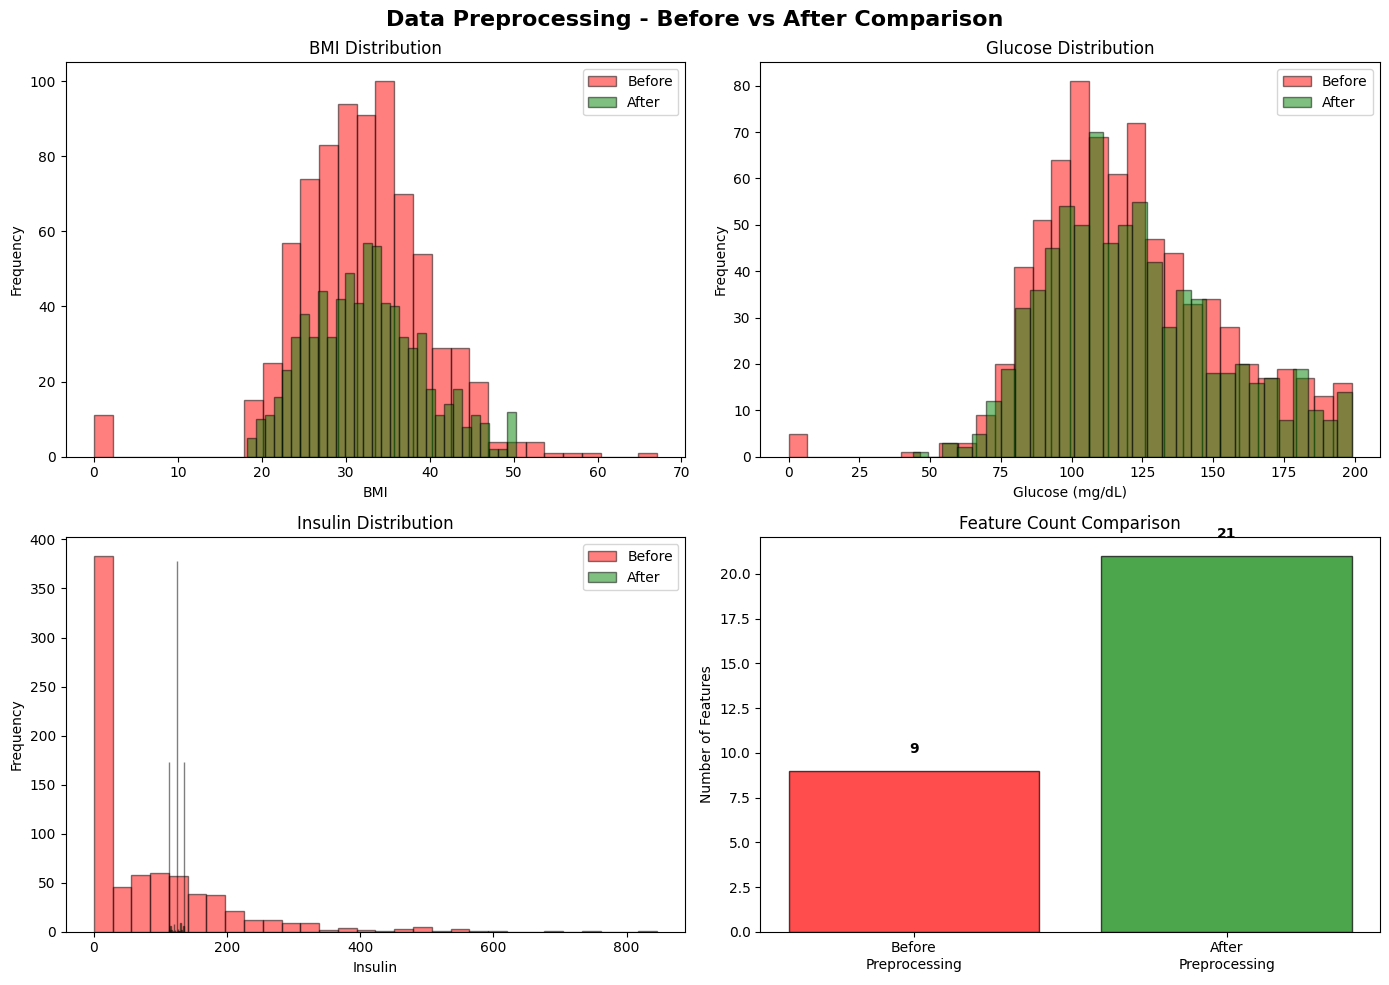

✅ Comparison visualization saved!


In [26]:
# Cell 12: Visualize Before vs After
print("=" * 50)
print("BEFORE vs AFTER COMPARISON")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Data Preprocessing - Before vs After Comparison', fontsize=16, fontweight='bold')

# BMI distribution
axes[0, 0].hist(diabetes_df['BMI'], bins=30, alpha=0.5, label='Before', color='red', edgecolor='black')
axes[0, 0].hist(diabetes_processed['BMI'], bins=30, alpha=0.5, label='After', color='green', edgecolor='black')
axes[0, 0].set_title('BMI Distribution')
axes[0, 0].set_xlabel('BMI')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Glucose distribution
axes[0, 1].hist(diabetes_df['Glucose'], bins=30, alpha=0.5, label='Before', color='red', edgecolor='black')
axes[0, 1].hist(diabetes_processed['Glucose'], bins=30, alpha=0.5, label='After', color='green', edgecolor='black')
axes[0, 1].set_title('Glucose Distribution')
axes[0, 1].set_xlabel('Glucose (mg/dL)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Insulin distribution
axes[1, 0].hist(diabetes_df['Insulin'], bins=30, alpha=0.5, label='Before', color='red', edgecolor='black')
axes[1, 0].hist(diabetes_processed['Insulin'], bins=30, alpha=0.5, label='After', color='green', edgecolor='black')
axes[1, 0].set_title('Insulin Distribution')
axes[1, 0].set_xlabel('Insulin')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Feature count comparison
categories = ['Before\nPreprocessing', 'After\nPreprocessing']
feature_counts = [diabetes_df.shape[1], diabetes_encoded.shape[1]]
axes[1, 1].bar(categories, feature_counts, color=['red', 'green'], edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Feature Count Comparison')
axes[1, 1].set_ylabel('Number of Features')
for i, v in enumerate(feature_counts):
    axes[1, 1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comparison visualization saved!")


In [27]:
# Cell 13: Final Summary
print("\n" + "=" * 70)
print("PHASE 2 COMPLETE: DATA PREPROCESSING & FEATURE ENGINEERING")
print("=" * 70)

print("\n✅ Completed Tasks:")
print("   1. ✓ Handled missing values (replaced 0s with median)")
print("   2. ✓ Handled outliers using IQR method")
print("   3. ✓ Created categorical features (BMI, Glucose, BP categories)")
print("   4. ✓ Engineered risk scores")
print("   5. ✓ Created interaction features")
print("   6. ✓ Encoded categorical variables")
print("   7. ✓ Analyzed feature correlations")
print("   8. ✓ Saved processed datasets")

print("\n📁 Files Generated:")
print("   - data/processed/diabetes_processed.csv")
print("   - data/processed/diabetes_ml_ready.csv")
print("   - results/preprocessing_report.csv")
print("   - results/plots/outliers_before.png")
print("   - results/plots/outliers_after.png")
print("   - results/plots/risk_distribution.png")
print("   - results/plots/feature_correlation.png")
print("   - results/plots/preprocessing_comparison.png")

print("\n📊 Dataset Summary:")
print(f"   Original features: {diabetes_df.shape[1]}")
print(f"   Final features: {diabetes_encoded.shape[1]}")
print(f"   ML-ready features: {len(ml_features)}")
print(f"   Total samples: {len(diabetes_encoded)}")

print("\n🚀 Ready for Phase 3: Model Training!")



PHASE 2 COMPLETE: DATA PREPROCESSING & FEATURE ENGINEERING

✅ Completed Tasks:
   1. ✓ Handled missing values (replaced 0s with median)
   2. ✓ Handled outliers using IQR method
   3. ✓ Created categorical features (BMI, Glucose, BP categories)
   4. ✓ Engineered risk scores
   5. ✓ Created interaction features
   6. ✓ Encoded categorical variables
   7. ✓ Analyzed feature correlations
   8. ✓ Saved processed datasets

📁 Files Generated:
   - data/processed/diabetes_processed.csv
   - data/processed/diabetes_ml_ready.csv
   - results/preprocessing_report.csv
   - results/plots/outliers_before.png
   - results/plots/outliers_after.png
   - results/plots/risk_distribution.png
   - results/plots/feature_correlation.png
   - results/plots/preprocessing_comparison.png

📊 Dataset Summary:
   Original features: 9
   Final features: 21
   ML-ready features: 16
   Total samples: 768

🚀 Ready for Phase 3: Model Training!
